# Library Energy Consumption Forecasting with Extra Trees

**Task:** Predict library power consumption 24 hours ahead (144 steps at 10-minute resolution)
**Model:** `ExtraTreesRegressor`, benchmarked against the same naive persistence baseline and
Linear Regression used in the LightGBM notebook
**Data:** `library_cleaned_master.csv` — 10-minute readings, February 2014 to November 2017
**Split strategy:** 70% train / 30% test, chronological — identical to the LightGBM notebook

**Fairness note:** every cell up through the train/test split reproduces the LightGBM notebook's
data pipeline exactly (same features, same target, same split, same baselines). Only the model
itself, its hyperparameter grid, and the final-fit step change — the places where Extra Trees
genuinely needs different handling than a gradient boosting model. Each change is called out
explicitly in the markdown so the comparison at the end is apples-to-apples.

## 1. Imports

Same imports as the LightGBM notebook, except `lightgbm`/`LGBMRegressor` is replaced with
`sklearn.ensemble.ExtraTreesRegressor`. `np.random.seed(42)` and `random_state=42` are kept
throughout for reproducibility, matching the original notebook's convention.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)                      # global seed for reproducibility
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")

## 2. Load and Inspect Data

Identical to the LightGBM notebook: read the CSV, parse `timestamp` as a real datetime, and sort
chronologically. This is the same `library_cleaned_master.csv` — no re-cleaning happens here.

In [4]:
df = pd.read_csv("library_cleaned_master.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])          # parse timestamp string -> datetime
df = df.sort_values("timestamp").reset_index(drop=True)    # enforce chronological order

print("Shape:", df.shape)
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
print()
print("Missing values per column:")
print(df.isnull().sum())

Shape: (118776, 7)
Date range: 2014-02-16 00:20:00+05:30 to 2017-11-03 23:50:00+05:30

Missing values per column:
timestamp          0
power              0
current            0
voltage            0
frequency          0
power_factor       0
occupancy_count    0
dtype: int64


In [5]:
df.head()

,timestamp,power,current,voltage,frequency,power_factor,occupancy_count
0,2014-02-16 00:20:00+05:30,6271.9930,8.991743,245.25345,50.227917,0.948552,4.0
1,2014-02-16 00:30:00+05:30,6266.4854,8.972734,245.40556,50.193413,0.949093,5.0
2,2014-02-16 00:40:00+05:30,6251.4180,8.953675,245.16708,50.148920,0.949744,5.0
3,2014-02-16 00:50:00+05:30,6345.1910,9.143141,243.07417,50.124634,0.951980,5.0
4,2014-02-16 01:00:00+05:30,6432.1733,9.251285,243.14775,50.100616,0.953440,5.0


## 3. Why Electrical Features Are Excluded

Same reasoning as the LightGBM notebook: `current`, `voltage`, `frequency`, and `power_factor` are
left out of the model inputs. `power` correlates with `current` at r ≈ 0.99 (near-restatement of
the target), `current` was partially reconstructed from `power` during cleaning (leakage risk),
and none of these instantaneous readings would be available at prediction time for a 24-hour-ahead
forecast anyway. This applies to any model trained on this data, not just LightGBM, so it carries
over unchanged.

## 4. Feature Engineering

Reused verbatim from the LightGBM notebook — calendar features, gap-aware lags, backward-looking
rolling means, and the 24-hour-ahead target. Keeping this identical is what makes the model
comparison fair: both models see exactly the same rows and columns.

### 4.1 Calendar features

In [6]:
df["hour"] = df["timestamp"].dt.hour                 # hour of day, 0-23
df["dayofweek"] = df["timestamp"].dt.dayofweek       # day of week, 0=Monday ... 6=Sunday
df["month"] = df["timestamp"].dt.month               # month, 1-12
df["day_of_year"] = df["timestamp"].dt.dayofyear      # continuous seasonal position, 1-365
df["weekend"] = (df["dayofweek"] >= 5).astype(int)    # 1 if Saturday/Sunday, else 0

### 4.2 Lag features (gap-aware)

This dataset has 1,124 gaps larger than 10 minutes. A plain `shift(144)` would sometimes pull a
value from days before a gap and mislabel it "yesterday." Each lag here takes the naive shift, then
checks the rolling **maximum** of `time_diff` over the same window — if a gap sits inside the
window, the value is forced to `NaN` instead of being silently wrong.

In [7]:
df["time_diff"] = df["timestamp"].diff().dt.total_seconds() / 60   # minutes since previous row

for lag in [144, 1008]:
    naive_shift = df["power"].shift(lag)                                        # plain lag
    max_gap_in_window = df["time_diff"].rolling(window=lag, min_periods=1).max()  # worst gap in window
    gap_present = max_gap_in_window > 10                                        # >10 min = real gap
    df[f"power_lag_{lag}"] = naive_shift.where(~gap_present, np.nan)             # NaN out unsafe lags

### 4.3 Rolling mean features (backward-looking only)

`.shift(1)` before `.rolling(...)` guarantees the window for row *t* only ever includes data
strictly before *t* — no future leakage.

In [8]:
df["power_roll_mean_144"] = df["power"].shift(1).rolling(window=144, min_periods=100).mean()
df["power_roll_mean_1008"] = df["power"].shift(1).rolling(window=1008, min_periods=700).mean()

### 4.4 Target variable

`target` is `power` shifted 144 rows backward in time — the reading 24 hours into the future
relative to each row.

In [9]:
df["target"] = df["power"].shift(-144)   # power 24 hours into the future

### 4.5 Drop incomplete rows

Removes rows with any `NaN` — from insufficient history at the start, from gap-aware lag/rolling
invalidation, and from the undefined target at the end of the series. This drops noticeably more
than a naive shift/rolling would, because the gap-aware logic intentionally invalidates any window
that overlaps one of the 1,124 recorded gaps.

In [10]:
rows_before = len(df)
df_clean = df.dropna().reset_index(drop=True)
rows_after = len(df_clean)

print(f"Rows before dropna: {rows_before:,}")
print(f"Rows after dropna:  {rows_after:,}")
print(f"Rows dropped:       {rows_before - rows_after:,}  ({(rows_before-rows_after)/rows_before:.1%})")

Rows before dropna: 118,776
Rows after dropna:  41,248
Rows dropped:       77,528  (65.3%)


## 5. Feature List and Train/Test Split

Same `FEATURES`, `TARGET`, and 70/30 chronological split as the LightGBM notebook — no shuffling,
since shuffling a time series before splitting would leak future information into training. This
is the single most important thing to keep identical for a fair comparison.

In [11]:
FEATURES = [
    "power",              # current power reading at time t (lag_0)
    "occupancy_count",    # number of people in building
    "hour", "dayofweek", "month", "weekend",
    "power_lag_144",      # same time yesterday
    "power_lag_1008",     # same time last week
]
TARGET = "target"

n = len(df_clean)
train_end = int(n * 0.70)

train_df = df_clean.iloc[:train_end]
test_df  = df_clean.iloc[train_end:]

X_train = train_df[FEATURES]; y_train = train_df[TARGET]
X_test  = test_df[FEATURES];  y_test  = test_df[TARGET]

print(f"Train: {len(train_df):,} rows  |  {train_df['timestamp'].min()}  to  {train_df['timestamp'].max()}")
print(f"Test:  {len(test_df):,} rows  |  {test_df['timestamp'].min()}  to  {test_df['timestamp'].max()}")

Train: 28,873 rows  |  2014-02-26 10:30:00+05:30  to  2016-11-20 12:50:00+05:30
Test:  12,375 rows  |  2016-11-20 13:00:00+05:30  to  2017-11-02 23:50:00+05:30


## 6. Baseline Models

Identical baselines to the LightGBM notebook, recomputed here so this notebook is fully
self-contained. Numbers should match the friend's notebook exactly, since the data and split are
the same — if they don't, something upstream diverged.

### 6.1 Naive Persistence

In [12]:
y_pred_persist = X_test["power"].values     # predict power(t+24h) = power(t)

mae_persist = mean_absolute_error(y_test, y_pred_persist)
rmse_persist = np.sqrt(mean_squared_error(y_test, y_pred_persist))
r2_persist = r2_score(y_test, y_pred_persist)

print("Naive Persistence Baseline")
print(f"  MAE:  {mae_persist:>8.0f}")
print(f"  RMSE: {rmse_persist:>8.0f}")
print(f"  R2:   {r2_persist:>8.4f}")

Naive Persistence Baseline
  MAE:      3580
  RMSE:     6225
  R2:     0.3866


### 6.2 Linear Regression

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Baseline")
print(f"  MAE:  {mae_lr:>8.0f}")
print(f"  RMSE: {rmse_lr:>8.0f}")
print(f"  R2:   {r2_lr:>8.4f}")

Linear Regression Baseline
  MAE:      3989
  RMSE:     5743
  R2:     0.4779


## 7. TimeSeriesSplit Cross-Validation (5 Folds)

Run only on `X_train`/`y_train` — the test set is never touched here. Same `TimeSeriesSplit(n_splits=5, gap=144)`
as the LightGBM notebook, with the same 24-hour gap between each fold's train and validation slice.
The model itself is swapped for `ExtraTreesRegressor` with reasonable starting hyperparameters,
mirroring the structure of the LightGBM notebook's untuned CV pass in Section 8.

In [14]:
tscv = TimeSeriesSplit(n_splits=5, gap=144)

fold_metrics = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    X_tr_fold, X_val_fold = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = ExtraTreesRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_tr_fold, y_tr_fold)
    preds = model.predict(X_val_fold)

    mae = mean_absolute_error(y_val_fold, preds)
    rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
    r2 = r2_score(y_val_fold, preds)
    fold_metrics.append((mae, rmse, r2))

    print(f"Fold {fold} | MAE: {mae:>6.0f}  RMSE: {rmse:>6.0f}  R2: {r2:.4f}")

fold_arr = np.array(fold_metrics)
mean_mae, mean_rmse, mean_r2 = fold_arr.mean(axis=0)
std_mae, std_rmse, std_r2 = fold_arr.std(axis=0)

print("-" * 47)
print(f"Mean   | MAE: {mean_mae:>6.0f}  RMSE: {mean_rmse:>6.0f}  R2: {mean_r2:.4f}")
print(f"Std    | MAE: {std_mae:>6.0f}  RMSE: {std_rmse:>6.0f}  R2: {std_r2:.4f}")

Fold 1 | MAE:   5268  RMSE:   8025  R2: 0.0864
Fold 2 | MAE:   4265  RMSE:   5596  R2: 0.3640
Fold 3 | MAE:   3059  RMSE:   4337  R2: 0.4909
Fold 4 | MAE:   2463  RMSE:   3047  R2: 0.7604
Fold 5 | MAE:   2970  RMSE:   4408  R2: 0.6505
-----------------------------------------------
Mean   | MAE:   3605  RMSE:   5082  R2: 0.4704
Std    | MAE:   1021  RMSE:   1678  R2: 0.2348


## 8. Hyperparameter Tuning

Same search strategy as the LightGBM notebook — `RandomizedSearchCV` with `n_iter=20` and
`cv=TimeSeriesSplit(n_splits=3, gap=144)` scoring on R². Two things change here, both for reasons
specific to Extra Trees rather than arbitrary choices:

- **The parameter grid is different.** LightGBM's boosting parameters (`learning_rate`,
  `num_leaves`, `reg_alpha`/`reg_lambda`) don't exist for Extra Trees. Instead the grid covers
  `n_estimators`, `max_depth`, `max_features` (how many features each split considers —
  Extra Trees' key source of extra randomness), `min_samples_split`, `min_samples_leaf`, and
  `bootstrap`.
- **`n_jobs=-1` instead of `n_jobs=1`.** The LightGBM notebook forces `n_jobs=1` specifically to
  avoid exhausting Colab's RAM during parallel boosting fits. Extra Trees fits are lighter weight
  and embarrassingly parallel across trees, so there's no equivalent RAM pressure — using all
  cores here is a legitimate model-specific optimization, not a shortcut that biases the
  comparison.

In [15]:
param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [4, 6, 8, 10],              # was [10, 20, 30, None] - cap depth
    "max_features": ["sqrt", "log2", 0.5],   # was up to 1.0 - force feature subsampling
    "min_samples_split": [10, 20, 30],       # was down to 2 - require bigger nodes
    "min_samples_leaf": [10, 20, 30],        # was down to 1 - force bigger leaves
    "bootstrap": [True],                     # was [False, True] - always row-subsample
}

search = RandomizedSearchCV(
    ExtraTreesRegressor(random_state=42, n_jobs=-1),
    param_grid,
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=3, gap=144),
    scoring="r2",
    n_jobs=1,       # keep the search loop itself sequential; parallelism happens inside each fit
    random_state=42,
    verbose=0,
)
search.fit(X_train, y_train)

print("Best parameters found:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV R2 (3-fold, tuning only): {search.best_score_:.4f}")

Best parameters found:
  n_estimators: 800
  min_samples_split: 20
  min_samples_leaf: 10
  max_features: 0.5
  max_depth: 10
  bootstrap: True

Best CV R2 (3-fold, tuning only): 0.6008


## 9. Final Model Training

Trains on the **full** `X_train`/`y_train` using the best hyperparameters. Unlike the LightGBM
notebook, there is no early-stopping / monitor-set carve-out here: `ExtraTreesRegressor` builds a
fixed forest of fully-grown, independent trees rather than an additive sequence of boosted trees,
so there's no notion of "stop adding trees once validation loss stalls." Overfitting for Extra
Trees is controlled instead through the hyperparameters already tuned above — `max_depth`,
`min_samples_leaf`, `min_samples_split`, and `max_features` — which is why that grid matters more
here than it would for a boosting model. `X_test`/`y_test` are still never referenced in this
cell.

In [16]:
final_model = ExtraTreesRegressor(**search.best_params_, random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

print(f"Number of trees in final forest: {final_model.n_estimators}")

Number of trees in final forest: 800


## 10. Final Evaluation

Predictions on `X_test` are computed here for the first and only time — same discipline as the
LightGBM notebook. Compare this table's Extra Trees row directly against the friend's printed
LightGBM row (and the baselines above, which should match hers exactly since the data is
identical).

In [17]:
y_pred_et = final_model.predict(X_test)

mae_et = mean_absolute_error(y_test, y_pred_et)
rmse_et = np.sqrt(mean_squared_error(y_test, y_pred_et))
r2_et = r2_score(y_test, y_pred_et)

print("=" * 52)
print(f"  {'Model':<22}{'MAE':>8}{'RMSE':>10}{'R2':>10}")
print("=" * 52)
print(f"  {'Naive Persistence':<22}{mae_persist:>8.0f}{rmse_persist:>10.0f}{r2_persist:>10.4f}")
print(f"  {'Linear Regression':<22}{mae_lr:>8.0f}{rmse_lr:>10.0f}{r2_lr:>10.4f}")
print(f"  {'Extra Trees (Final)':<22}{mae_et:>8.0f}{rmse_et:>10.0f}{r2_et:>10.4f}")
print("=" * 52)
print()
print("Fill in from the LightGBM notebook's own Section 11 printout to complete the comparison:")
print(f"  {'LightGBM (Final)':<22}{'?':>8}{'?':>10}{'?':>10}")

  Model                      MAE      RMSE        R2
  Naive Persistence         3580      6225    0.3866
  Linear Regression         3989      5743    0.4779
  Extra Trees (Final)       3271      4495    0.6801

Fill in from the LightGBM notebook's own Section 11 printout to complete the comparison:
  LightGBM (Final)             ?         ?         ?


If Extra Trees' MAE/RMSE are noticeably lower and R² noticeably higher than both baselines,
it's learning real structure. Compare its numbers against LightGBM's printed row from her
notebook — since every upstream step (features, target, split) is identical, any difference in
these three metrics reflects the models themselves, not the data setup.

### 10.1 Train vs. Test — Overfitting Check

Section 10 only shows test-set performance, which tells you how good the model is but not why.
Computing the same metrics on `X_train`/`y_train` and comparing the two reveals the model's
bias/variance regime:

- **Train ≈ Test** → the model generalizes; hyperparameter tuning (`max_depth`, `min_samples_leaf`,
  `min_samples_split`) is doing its job.
- **Train ≫ Test** (e.g. R² 0.95 vs 0.69) → **overfitting** — the forest is partly memorizing
  training rows rather than learning patterns that transfer.
- **Both low** → **underfitting** — the model or features aren't capturing enough signal even on
  data it has already seen.

This is a read-only diagnostic — it doesn't change `final_model` or retrain anything, it just
evaluates the same fitted model on both sets.

In [18]:
y_pred_train = final_model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("=" * 52)
print(f"  {'Set':<22}{'MAE':>8}{'RMSE':>10}{'R2':>10}")
print("=" * 52)
print(f"  {'Train':<22}{mae_train:>8.0f}{rmse_train:>10.0f}{r2_train:>10.4f}")
print(f"  {'Test':<22}{mae_et:>8.0f}{rmse_et:>10.0f}{r2_et:>10.4f}")
print("=" * 52)

r2_gap = r2_train - r2_et
print(f"\nR2 gap (train - test): {r2_gap:.4f}")
if r2_gap > 0.15:
    print("-> Large gap: model is overfitting the training set.")
elif r2_train < 0.5:
    print("-> Both scores are low: model may be underfitting.")
else:
    print("-> Gap is modest: model is generalizing reasonably well.")

  Set                        MAE      RMSE        R2
  Train                     2099      3025    0.8094
  Test                      3271      4495    0.6801

R2 gap (train - test): 0.1292
-> Gap is modest: model is generalizing reasonably well.


## 11. Feature Importance

`ExtraTreesRegressor.feature_importances_` reports **mean decrease in impurity (MDI)** — how much
each feature reduces variance on average across all splits where it was used, weighted by how many
samples reach that split. This is conceptually similar to LightGBM's default "split count"
importance (both answer "which features does the model lean on") but the two numbers are on
**different scales** and shouldn't be plotted on the same axis or compared numerically — only the
relative ranking of features is comparable between the two notebooks.

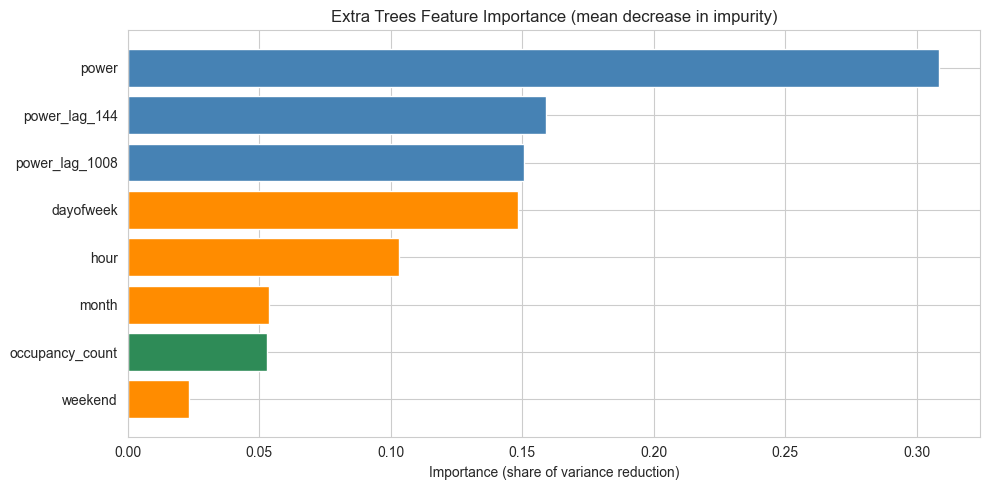

In [19]:
importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=True)

lag_roll_features = {"power", "power_lag_144", "power_lag_1008", "power_roll_mean_144", "power_roll_mean_1008"}
calendar_features = {"hour", "dayofweek", "month", "day_of_year", "weekend"}

def color_for(feat):
    if feat in lag_roll_features:
        return "steelblue"
    elif feat in calendar_features:
        return "darkorange"
    else:                                   # occupancy_count
        return "seagreen"

colors = [color_for(f) for f in importance_df["feature"]]

plt.figure(figsize=(10, 5))
plt.barh(importance_df["feature"], importance_df["importance"], color=colors)
plt.title("Extra Trees Feature Importance (mean decrease in impurity)")
plt.xlabel("Importance (share of variance reduction)")
plt.tight_layout()
plt.show()

## 12. Visualisations

Same three views as the LightGBM notebook: a zoomed-in time series, a full-test scatter plot, and
a residual histogram — using `y_pred_et` in place of `y_pred_lgb`.

### 12.1 Actual vs. Predicted — first 1,000 test rows

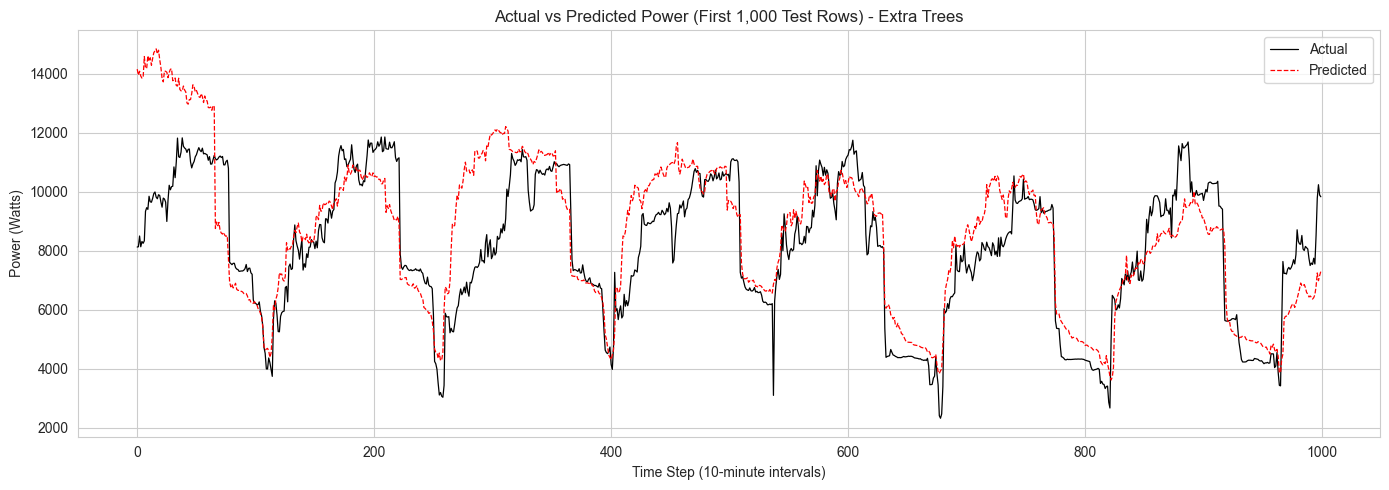

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:1000], label="Actual", color="black", linewidth=0.9)
plt.plot(y_pred_et[:1000], label="Predicted", color="red", linestyle="--", linewidth=0.9)
plt.title("Actual vs Predicted Power (First 1,000 Test Rows) - Extra Trees")
plt.xlabel("Time Step (10-minute intervals)")
plt.ylabel("Power (Watts)")
plt.legend()
plt.tight_layout()
plt.show()

### 12.2 Actual vs. Predicted — full test set (scatter)

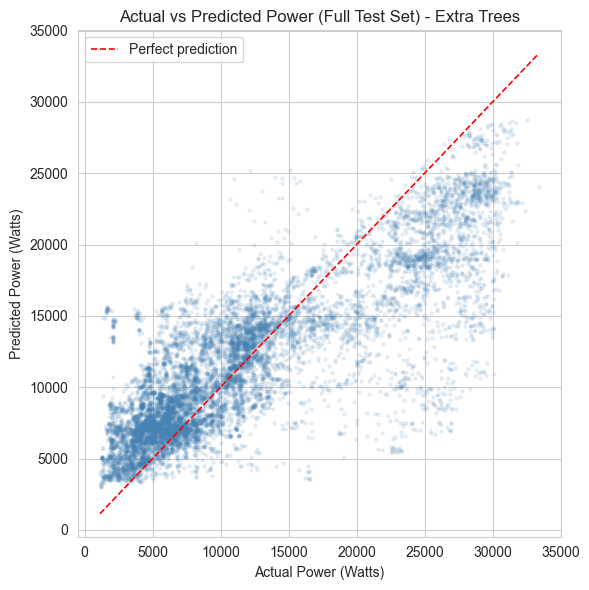

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_et, alpha=0.1, s=5, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=1.2, label="Perfect prediction")
plt.title("Actual vs Predicted Power (Full Test Set) - Extra Trees")
plt.xlabel("Actual Power (Watts)")
plt.ylabel("Predicted Power (Watts)")
plt.legend()
plt.tight_layout()
plt.show()

### 12.3 Residual histogram

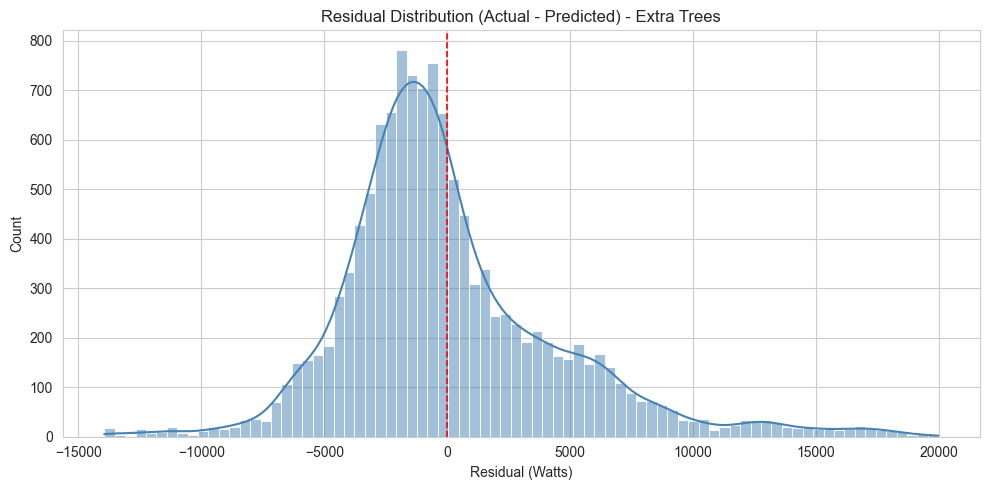

Mean residual: 65.32
Std residual:  4494.72


In [22]:
residuals = y_test - y_pred_et

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=80, kde=True, color="steelblue")
plt.axvline(0, color="red", linestyle="--", linewidth=1.2)
plt.title("Residual Distribution (Actual - Predicted) - Extra Trees")
plt.xlabel("Residual (Watts)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std residual:  {residuals.std():.2f}")

## 13. What's the Same and What's Different vs. the LightGBM Notebook

**Kept identical (this is what makes the comparison fair):**
- Source data, cleaning state, and excluded electrical features
- `FEATURES` list and `TARGET` definition
- Gap-aware lag/rolling feature logic and the dropna step
- 70/30 chronological train/test split (no shuffling)
- Both baselines (persistence, linear regression)
- `TimeSeriesSplit(gap=144)` for both the 5-fold report and the 3-fold tuning CV
- `RandomizedSearchCV` with `n_iter=20`, scoring `"r2"`, `random_state=42`
- Test set touched exactly once, at final evaluation

**Changed, and why each change is legitimate rather than a fairness violation:**
- **Hyperparameter grid** — swapped for parameters that actually exist for Extra Trees
  (`max_features`, `min_samples_leaf`, `min_samples_split`, `bootstrap` instead of
  `learning_rate`, `num_leaves`, `reg_alpha`/`reg_lambda`)
- **No early stopping / no monitor-set carve-out** — Extra Trees has no iterative boosting
  process for early stopping to interrupt; the full training set is used
- **`n_jobs=-1` during tuning and final fit** — Extra Trees doesn't have LightGBM's Colab RAM
  constraint under parallel fits, so there's no reason to force `n_jobs=1` here
- **Feature importance metric** — mean decrease in impurity instead of split count; comparable
  in ranking, not in absolute scale

## 14. Limitations

Same structural limitations as the LightGBM notebook, since they come from the data rather than
the model:

1. **No weather data** — temperature is a major driver of HVAC load and isn't available here.
2. **No holiday calendar** — the model can't distinguish holidays/breaks from regular weekdays.
3. **Static model** — trained once; consumption patterns may drift over time without retraining.
4. **Sensor gaps** — 1,124 gaps >10 minutes found. Gap-aware engineering prevents corruption, but
   rows near a gap still carry less complete history.
5. **24-hour horizon only** — a full next-24-hours trajectory would need recursive/multi-output
   forecasting, which is outside this notebook's scope.

Additionally, Extra Trees (like Random Forest) cannot extrapolate beyond the range of `power`
values seen in training — since consumption drifts upward over the 2014–2017 span, this is worth
watching for in the residual plot above (a systematic bias on the highest test-set values would be
the tell).

## 15. Conclusion

This notebook reproduces the LightGBM notebook's exact data pipeline — features, target, gap-aware
lags/rolling means, chronological split, and both baselines — and swaps in `ExtraTreesRegressor`
as the model, tuned via the same `RandomizedSearchCV`/`TimeSeriesSplit` scheme. The MAE/RMSE/R²
table in Section 10 is directly comparable against the friend's LightGBM results, since every
upstream step through the train/test split is identical; differences in final performance reflect
the two model families (gradient-boosted trees vs. an extremely randomized forest), not
differences in data handling.